In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


In [2]:
param_file = "/Users/vilasini/Documents/WALE/data/selected_params_halofit_unique.npy"
param_table = np.load(param_file)
param_table

from typing import Dict, Any

PARAM_NAMES = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

def load_cosmology_from_param_table(param_file: str, cosmo_index: int = 0) -> Dict[str, Any]:
    """
    Load cosmology parameters from a numpy file and return a dict of standard names.

    Supports:
    - numeric 2D arrays of shape (n_samples, 6)
    - numeric 1D arrays of length 6 (single sample)
    - structured numpy arrays with named fields (will attempt to map by PARAM_NAMES)

    Returned keys:
    - h, Oc (Omega_c), Ob (Omega_b), w (w0), wa, sigma8, Om, ns, H0
    """
    data = np.load(param_file, allow_pickle=True)

    # Structured dtype with names?
    if hasattr(data, "dtype") and data.dtype.names:
        # Try to map by latex labels or common equivalents
        def get_field(name_candidates):
            for nm in name_candidates:
                if nm in data.dtype.names:
                    return data[nm][cosmo_index] if data.ndim > 0 else data[nm].item()
            return None

        # common possible field names to check
        candidates = {
            "Omega_m": [r"$\\Omega_{m}$", "Omega_m", "Om", "omega_m", "omegam"],
            "sigma8": [r"$\\sigma_8$", "sigma8", "s8"],
            "w0": [r"$w_0$", "w0", "w"],
            "H0": [r"$H_0$", "H0", "h0"],
            "ns": [r"$n_s$", "ns"],
            "Omega_b": [r"$\\Omega_b$", "Omega_b", "Ob", "omegab"],
        }

        Omega_m = get_field(candidates["Omega_m"])
        sigma8 = get_field(candidates["sigma8"])
        w0 = get_field(candidates["w0"])
        H0 = get_field(candidates["H0"])
        ns = get_field(candidates["ns"])
        Omega_b = get_field(candidates["Omega_b"])

    else:
        # Numeric array: accept 1D length-6 or 2D samples x 6
        arr = np.asarray(data)
        if arr.ndim == 1 and arr.size == 6:
            row = arr
        elif arr.ndim == 2 and arr.shape[1] == 6:
            row = arr[cosmo_index]
        else:
            raise ValueError(f"Unexpected shape for param_table: {arr.shape}. Expect (6,) or (N,6).")

        Omega_m, sigma8, w0, H0, ns, Omega_b = row

    # Convert / compute standard quantities
    H0 = float(H0)
    h = H0 / 100.0
    Om = float(Omega_m)
    Ob = float(Omega_b)
    Oc = Om - Ob             # cold dark matter density
    w = float(w0)
    wa = 0.0                  # default unless present in table
    sigma8 = float(sigma8)
    ns = float(ns)

    return {
        "h": h,
        "Oc": Oc,
        "Ob": Ob,
        "w": w,
        "wa": wa,
        "sigma8": sigma8,
        "Om": Om,
        "ns": ns,
        "H0": H0,
    }

# Example usage:
# param_file = "/path/to/selected_params_halofit_unique.npy"
# params = load_cosmology_from_param_table(param_file, cosmo_index=5)
# h = params["h"]; Oc = params["Oc"]; Ob = params["Ob"]; ...

In [14]:
cosmogrid_params = np.load("../data/selected_params_halofit.npy")

# cosmogrid_kappa_old = np.load("../data/all_kappas_halofit_nobaryons_bin4.npy")
# cosmogrid_l1norms_old = np.load("../data/all_l1_norms_halofit_nobaryons_bin4.npy")
# cosmogrid_variances_old = np.load("../data/all_variances_halofit_nobaryons_bin4.npy")

cosmogrid_kappa = np.load("../data_new/all_kappas_halofit_nobaryons_bin4_theta30.0_actually_nobar.npy")
cosmogrid_l1norms = np.load("../data_new/all_l1_norms_halofit_nobaryons_bin4_theta30.0_actually_nobar.npy")
cosmogrid_variances = np.load("../data_new/all_variances_halofit_nobaryons_bin4_theta30.0_nobaryons.npy")

cosmogrid_kappa = np.load("../data_new/grid/all_kappas_halofit_nobaryons_bin4_theta60.0_ratio2.0.npy")
cosmogrid_l1norms = np.load("../data_new/grid/all_l1_norms_halofit_nobaryons_bin4_theta60.0_ratio2.0.npy")
cosmogrid_variances = np.load("../data_new/grid/all_variances_halofit_nobaryons_bin4_theta60.0_ratio2.0.npy")

# cosmogrid_kappa = np.load("../data_new/all_kappas_halofit_nobaryons_bin4_theta20.0_actually_nobar.npy")
# cosmogrid_l1norms = np.load("../data_new/all_l1_norms_halofit_nobaryons_bin4_theta20.0_actually_nobar.npy")
# cosmogrid_variances = np.load("../data_new/all_variances_halofit_nobaryons_bin4_theta20.0_actually_nobar.npy")

# cosmogrid_kappa = np.load("../data/all_kappas_fiducial_nobaryons_bin4_theta30.0.npy")
# cosmogrid_l1norms = np.load("../data/all_l1_norms_fiducial_nobaryons_bin4_theta30.0.npy")
# cosmogrid_variances = np.load("../data/all_variances_fiducial_nobaryons_bin4_theta30.0.npy")
# cosmogrid_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
#          4.930e-02]])

cosmogrid_snr = cosmogrid_kappa / (cosmogrid_variances[:, np.newaxis] ** 0.5)


print("cg_kappa shape: ", cosmogrid_kappa.shape, "cg_l1norm_shape: ",cosmogrid_l1norms.shape, "cg_var shape: ",cosmogrid_variances.shape,"cg params shape: ", cosmogrid_params.shape)

id_zbin = 3  # Corresponds to the third redshift bin
nz_file = f"/Users/vilasini/Documents/WALE/data/nz/nz_stage3_{id_zbin+1}_GRID.txt"
print(f"Using n(z) file: {nz_file}")
theta1_input = 60.0  # Smoothing scale in arcmin
filter_type = 'tophat'

invalid_index = []
predictionl1 = []
predictionl1snr = []
cosmogrid=True


params = cosmogrid_params        # shape (1299, 6)

# find unique cosmologies
unique_params, inv = np.unique(params, axis=0, return_inverse=True)

# inv is an array of length 1299 giving the group number (0..185)
# Build a list of index groups
groups = [np.where(inv == i)[0] for i in range(len(unique_params))]
n_cosmo = len(groups)  # = 186

print(f"Found {n_cosmo} unique cosmologies from {len(params)} total realizations.")


kappa_fix = np.linspace(-0.01, 0.01, 400)
snr_fix   = np.linspace(-3,  3,   300)

cosmogrid_l1norm_mean_kappa = []
cosmogrid_l1norm_mean_snr   = []
cosmogrid_l1norm_std_kappa  = []
cosmogrid_l1norm_std_snr    = []
cosmogrid_variance_mean     = []
cosmogrid_variance_std      = []
cosmogrid_interp_l1_kappa = []
cosmogrid_interp_l1_snr = []

if n_cosmo>1:
    print("Multiple cosmologies detected; processing groups.")
    for idx in groups:
    # for idx in range(len(cosmogrid_variances)):
        # idx = list of rows belonging to one cosmology
        l1_group = cosmogrid_l1norms[idx]      # shape (n_real, Nkappa)
        k_group  = cosmogrid_kappa[idx]        # same shape
        snr_group = cosmogrid_snr[idx]         # same shape
        var_group = cosmogrid_variances[idx]   # shape (n_real,)

        # interpolate each realisation to fixed kappa grid
        interp_kappa = np.array([
            np.interp(kappa_fix, k_group[j], l1_group[j])
            for j in range(len(idx))
        ])

        # interpolate each realisation to fixed snr grid
        interp_snr = np.array([
            np.interp(snr_fix, snr_group[j], l1_group[j])
            for j in range(len(idx))
        ])

        # mean across realisations for this cosmology
        cosmogrid_l1norm_mean_kappa.append(interp_kappa.mean(axis=0))
        cosmogrid_l1norm_mean_snr.append(interp_snr.mean(axis=0))
        cosmogrid_l1norm_std_kappa.append(interp_kappa.std(axis=0))
        cosmogrid_l1norm_std_snr.append(interp_snr.std(axis=0))
        cosmogrid_variance_mean.append(var_group.mean())
        cosmogrid_variance_std.append(var_group.std())
        cosmogrid_interp_l1_kappa.append(interp_kappa)
        cosmogrid_interp_l1_snr.append(interp_snr)
else:
    for i in range(len(cosmogrid_variances)):
        l1_group = cosmogrid_l1norms[i][np.newaxis, :]      # make it shape (1, Nkappa)
        k_group  = cosmogrid_kappa[i][np.newaxis, :]        # same shape
        snr_group = cosmogrid_snr[i][np.newaxis, :]         # same shape
        var_group = cosmogrid_variances[i][np.newaxis]     # shape (1,)
        # interpolate each realisation to fixed kappa grid
        interp_kappa = [np.interp(kappa_fix, k_group[0], l1_group[0]) ]
    

        # interpolate each realisation to fixed snr grid
        interp_snr = [np.interp(snr_fix, snr_group[0], l1_group[0]) ]
        cosmogrid_interp_l1_kappa.append(interp_kappa)
        cosmogrid_interp_l1_snr.append(interp_snr)
    cosmogrid_interp_l1_kappa = np.array(cosmogrid_interp_l1_kappa) #change from shape (200,1,400) to (1,200,400)
    cosmogrid_interp_l1_kappa = cosmogrid_interp_l1_kappa.squeeze(axis=1)
    cosmogrid_interp_l1_kappa = cosmogrid_interp_l1_kappa[np.newaxis, :, :]
    
    cosmogrid_interp_l1_snr = np.array(cosmogrid_interp_l1_snr)
    cosmogrid_interp_l1_snr = cosmogrid_interp_l1_snr.squeeze(axis=1)
    cosmogrid_interp_l1_snr = cosmogrid_interp_l1_snr[np.newaxis, :, :]

    print("the shapes: ", cosmogrid_interp_l1_kappa.shape, cosmogrid_interp_l1_snr.shape)
    # mean across realizations for this cosmology
    cosmogrid_l1norm_mean_kappa = np.mean(cosmogrid_interp_l1_kappa, axis=0)
    cosmogrid_l1norm_mean_snr = np.mean(cosmogrid_interp_l1_snr, axis=0)
    cosmogrid_l1norm_std_kappa = np.std(cosmogrid_interp_l1_kappa, axis=0)
    cosmogrid_l1norm_std_snr = np.std(cosmogrid_interp_l1_snr, axis=0)
    cosmogrid_variance_mean = [np.mean(var_group)]
    cosmogrid_variance_std = [np.std(var_group)]
    


# convert to arrays (shape: n_cosmo × grid size)
cosmogrid_l1norm_mean_kappa = np.array(cosmogrid_l1norm_mean_kappa)
cosmogrid_l1norm_mean_snr   = np.array(cosmogrid_l1norm_mean_snr)
cosmogrid_variance_mean     = np.array(cosmogrid_variance_mean)
cosmogrid_l1norm_std_kappa  = np.array(cosmogrid_l1norm_std_kappa)
cosmogrid_l1norm_std_snr    = np.array(cosmogrid_l1norm_std_snr)
cosmogrid_variance_std      = np.array(cosmogrid_variance_std)
# cosmogrid_interp_l1_kappa = np.array(cosmogrid_interp_l1_kappa)
# cosmogrid_interp_l1_snr = np.array(cosmogrid_interp_l1_snr)

# n_cosmo, cosmogrid_variance_mean, cosmogrid_l1norm_mean_kappa.shape

cg_kappa shape:  (1299, 400) cg_l1norm_shape:  (1299, 400) cg_var shape:  (1299,) cg params shape:  (1299, 6)
Using n(z) file: /Users/vilasini/Documents/WALE/data/nz/nz_stage3_4_GRID.txt
Found 186 unique cosmologies from 1299 total realizations.
Multiple cosmologies detected; processing groups.


In [32]:
from joblib import Parallel, delayed
import warnings
import numpy as np
from scipy.interpolate import CubicSpline

# ----------------------------------------------------------
# Fixed grids
# ----------------------------------------------------------

def process_unique_cosmology(cosmo_id):
    warnings.filterwarnings("ignore",
                        message="invalid value encountered in sqrt",
                        category=RuntimeWarning)

    warnings.filterwarnings("ignore",   
                        message="invalid value encountered in power",
                        category=RuntimeWarning)


    # ------------------------------------------------------
    # Group indices for this cosmology
    # ------------------------------------------------------
    real_indices = np.where(inv == cosmo_id)[0]
    print(f"[Cosmo {cosmo_id}] {len(real_indices)} realizations")

    # ------------------------------------------------------
    # Cosmology parameters
    # ------------------------------------------------------
    Om, sigma8, w, h100, ns, Ob = unique_params[cosmo_id]
    h  = h100 / 100.
    Oc = Om - Ob
    wa = 0.0

    # ------------------------------------------------------
    # 1) USE **ONLY COSMOGRID MEAN VARIANCE**
    # ------------------------------------------------------
    variance_mean = cosmogrid_variance_mean[cosmo_id]

    # ------------------------------------------------------
    # Representative realization values (ONLY for shape)
    # ------------------------------------------------------
    # rep_idx = real_indices[0]
    kappa_rep = kappa_fix #cosmogrid_kappa[rep_idx]      # x-axis for empirical curves
    snr_rep   = snr_fix #cosmogrid_snr[rep_idx]

    # ------------------------------------------------------
    # 2) Build LDT variables
    # ------------------------------------------------------
    

    variables = InitialiseVariables(
        h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
        dk=0.01, kmin=1e-3, kmax=.37,
        nz_file=nz_file, variability=False,
        theta1=theta1_input, nplanes=20, ns=ns
    )

    # Compute theory σ²
    variance = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
    variables.sigmasq_map = np.sum(
        variables.dchi * (variables.lensingweights**2) *
        np.array([
            variance.get_sig_slice(z, chi * variables.theta1_radian,
                                      chi * variables.theta2_radian)
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    )

    theory_sigmasq = compute_sigma_kappa_squared(
        theta1_input, variables.chis, variables.lensingweights,
        variables.redshifts, variables.cosmo.k, variables.cosmo.pnl,
        filter_type=filter_type, h=h
    )

    # ------------------------------------------------------
    # Recalibrate theory using cosmogrid **mean variance**
    # ------------------------------------------------------
    variables.recal_value = variables.sigmasq_map / variance_mean

    # print("the perturb variance:", theory_sigmasq)
    print("the ldt variance:", variables.sigmasq_map)
    print("the sim variance:", variance_mean)
    print("recalibration factor:", variables.recal_value)
    # ------------------------------------------------------
    # 3) Compute theory PDF(kappa)
    # ------------------------------------------------------
    smallest_positive, largest_negative = find_critical_points_for_cosmo(
        variables, variance, ngrid_critical=25,
        plot=False, min_z=0, max_z=5
    )

    if smallest_positive and largest_negative is not None:
        variables.lambdas = np.linspace(largest_negative,
                                        smallest_positive, 20)

    computed_PDF = computePDF(variables, variance,
                              plot_scgf=False,
                              kappa=kappa_rep)

    kappa_vals = computed_PDF.kappa_values
    pdf_vals   = computed_PDF.pdf_values
    pdf_vals = np.array(pdf_vals)
    pred_stats = get_moments(kappa_vals, pdf_vals)
    print(f"  predstats: mean: {pred_stats[0]}, variance: {pred_stats[1]}, s3: {pred_stats[2]:.3f}, kurtosis: {pred_stats[3]:.3f}, norm: {pred_stats[4]:.3f}") 

    # ------------------------------------------------------
    # 4) THEORY L1-norm vs kappa, snr
    # ------------------------------------------------------
    theory_l1_kappa = np.abs(kappa_vals) * pdf_vals

    norm_kappa = kappa_vals / np.sqrt(theory_sigmasq)
    theory_l1_snr = CubicSpline(norm_kappa, theory_l1_kappa)(snr_fix)

    # Interpolate theory to FIXED GRIDS
    theory_l1_kappa_fix = CubicSpline(kappa_vals, theory_l1_kappa)(kappa_fix)
    # theory_l1_kappa_fix = np.interp(kappa_fix, kappa_vals, theory_l1_kappa)

    # ------------------------------------------------------
    # 5) COSMOGRID MEAN CURVES ALREADY PRE-COMPUTED
    # ------------------------------------------------------
    cg_l1_mean_kappa = cosmogrid_l1norm_mean_kappa[cosmo_id]  # same shape as kappa_fix
    cg_l1_mean_snr   = cosmogrid_l1norm_mean_snr[cosmo_id]    # same shape as snr_fix
    cg_l1_std_kappa = cosmogrid_l1norm_std_kappa[cosmo_id]
    cg_l1_std_snr   = cosmogrid_l1norm_std_snr[cosmo_id]
    cg_var_mean      = cosmogrid_variance_mean[cosmo_id]
    cg_var_std      = cosmogrid_variance_std[cosmo_id]
    print(len(cg_l1_mean_kappa), cg_l1_mean_snr.shape)

    return {
        "cosmo_id": cosmo_id,
        "params": {
            "Om": Om, "sigma8": sigma8, "w": w,
            "h": h, "ns": ns, "Ob": Ob, "Oc": Oc, "wa": wa
        },
        

        # ----------------------------------------------------------
        # FIXED X-AXES
        # ----------------------------------------------------------
        "kappa_fix": kappa_fix,
        "snr_fix": snr_fix,

        # ----------------------------------------------------------
        # THEORY RESULTS
        # ----------------------------------------------------------
        "theory_l1_kappa_fix": theory_l1_kappa_fix,
        "theory_l1_snr_fix":  theory_l1_snr,
        "pred_stats": pred_stats,

        # ----------------------------------------------------------
        # COSMOGRID EMPIRICAL MEANS (precomputed)
        # ----------------------------------------------------------
        "cg_l1_kappa_mean": cg_l1_mean_kappa,
        "cg_l1_snr_mean":   cg_l1_mean_snr,
        "cg_variance_mean": cg_var_mean,
        "cg_variance_std":      cg_var_std,
        "cg_l1_kappa_std":      cg_l1_std_kappa,
        "cg_l1_snr_std":        cg_l1_std_snr,
        "cg_l1_kappa_realizations": cosmogrid_interp_l1_kappa[cosmo_id],
        "cg_l1_snr_realizations": cosmogrid_interp_l1_snr[cosmo_id],
    }


with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="invalid value encountered in power")
    
    # --- call the part that triggers the warning ---
    results = Parallel(n_jobs=7, verbose=10)(
        delayed(process_unique_cosmology)(cosmo_id)
        for cosmo_id in range(n_cosmo)
    )


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.


[Cosmo 0] 7 realizations
   Using scalar spectral index ns = 0.932665557861

Initialised Cosmology:
  h = 0.738553543091, Oc = 0.17097179412900002, Ob = 0.04023273468, w = -0.891297214508, wa = 0.0, sigma8 = 0.79253616333
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
[Cosmo 1] 7 realizations
   Using scalar spectral index ns = 0.942041320801

Initialised Cosmology:
  h = 0.687572174072, Oc = 0.16741691589399998, Ob = 0.044909133911, w = -1.086438926697, wa = 0.0, sigma8 = 0.824644470215
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
      Variability: disabled
[Cosmo 2] 7 realizations
   Using scalar spectral index ns = 0.91375

Initialised Cosmology:
  h = 0.814375, Oc = 0.17781249999999998, Ob = 0.0346875, w = -1.11440625, wa = 0.0, sigma8 = 0.68125
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
[

[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:   12.2s


[Cosmo 12] 7 realizations
   Using scalar spectral index ns = 0.942300720215

Initialised Cosmology:
  h = 0.695413665771, Oc = 0.183802261352, Ob = 0.047865829468, w = -1.054668861389, wa = 0.0, sigma8 = 0.837690734863
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
      Variability: disabled
      Variability: disabled
  predstats: mean: -8.090678509445337e-08, variance: 2.0442407828766577e-06, s3: -104.184, kurtosis: 0.107, norm: 1.000
400 (300,)
[Cosmo 13] 7 realizations
   Using scalar spectral index ns = 0.974203796387

Initialised Cosmology:
  h = 0.656351776123, Oc = 0.185519485474, Ob = 0.046942062378, w = -0.937814033508, wa = 0.0, sigma8 = 0.752149963379
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
      Variability: disabled
the ldt variance: 2.00567445962567e-06
the sim variance: 2.0812537829299013e-06
recalibration factor: 0.9636856764301787
the 

[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:   23.6s


...

[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed:  4.1min


  predstats: mean: -5.697641682018756e-07, variance: 3.8819563708061596e-06, s3: -67.095, kurtosis: 0.082, norm: 1.000
400 (300,)
[Cosmo 155] 7 realizations
   Using scalar spectral index ns = 0.986864776611

Initialised Cosmology:
  h = 0.738817214966, Oc = 0.322148551941, Ob = 0.043938789368, w = -1.064671726227, wa = 0.0, sigma8 = 0.77154006958
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
      Variability: disabled
  predstats: mean: -1.3443306153373188e-07, variance: 2.79578981270845e-06, s3: -72.064, kurtosis: 0.066, norm: 1.000
400 (300,)
[Cosmo 156] 7 realizations
   Using scalar spectral index ns = 0.958745117187

Initialised Cosmology:
  h = 0.684187011719, Oc = 0.321839599609, Ob = 0.044908447266, w = -1.029957397461, wa = 0.0, sigma8 = 0.752905273437
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
      Variability: disabled
  predstats: mean: -6.85

[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed:  4.5min


the ldt variance: 2.456313462443291e-06
the sim variance: 2.5302800213746965e-06
recalibration factor: 0.970767441426811
the ldt variance: 3.556423825910666e-06
the sim variance: 3.6741965774061e-06
recalibration factor: 0.9679459851931552
  predstats: mean: -4.039812183902333e-07, variance: 4.165039936579346e-06, s3: -66.131, kurtosis: 0.083, norm: 1.000
400 (300,)
the ldt variance: 2.3354015282369127e-06
the sim variance: 2.403496283756473e-06
recalibration factor: 0.9716684581624843
[Cosmo 174] 7 realizations
   Using scalar spectral index ns = 0.969406433105

Initialised Cosmology:
  h = 0.693144989014, Oc = 0.33983528137200003, Ob = 0.048412399292, w = -0.983904792786, wa = 0.0, sigma8 = 0.816786193848
  k-range: [0.001, 0.37] with step dk = 0.01

the angles are:  0.017453292519943295  and  0.03490658503988659
      Variability: disabled
the ldt variance: 4.067340377420891e-06
the sim variance: 4.157852847533394e-06
recalibration factor: 0.9782309587588703
the ldt variance: 3.8164

[Parallel(n_jobs=7)]: Done 186 out of 186 | elapsed:  5.0min finished


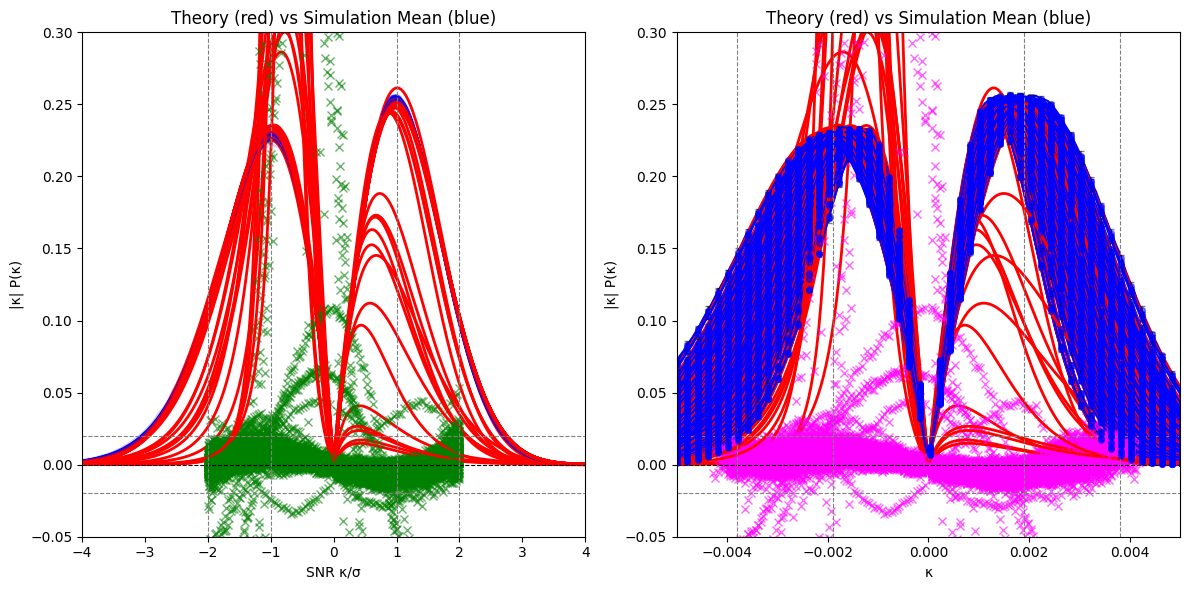

invalid predictions: 0


In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
counter = 0

for r in results:

    cosmo_id = r["cosmo_id"]
    # if cosmo_id > 20:
    #     continue

    # Fixed axes
    kappa_fix = r["kappa_fix"]
    snr_fix   = r["snr_fix"]

    # THEORY
    th_l1_kappa = r["theory_l1_kappa_fix"]
    th_l1_snr   = r["theory_l1_snr_fix"]
    pred_stats  = r["pred_stats"]
    # SIMULATION (mean across realizations)
    cg_l1_kappa_mean = r["cg_l1_kappa_mean"]
    cg_l1_kappa_std  = r["cg_l1_kappa_std"]
    cg_l1_snr_mean   = r["cg_l1_snr_mean"]
    cg_l1_snr_std    = r["cg_l1_snr_std"]

    cg_l1_kappa_real = r["cg_l1_kappa_realizations"]
    cg_l1_snr_real   = r["cg_l1_snr_realizations"]
    # print("the shapes of realisations: ", cg_l1_kappa_real.shape, cg_l1_snr_real.shape)

    #print the shapes:
    # print(cg_l1_kappa_mean.shape, cg_l1_snr_mean.shape)
    cg_var_mean = r["cg_variance_mean"]
    sigma = np.sqrt(cg_var_mean)

    # if np.any(th_l1_snr <0):
    #     print(f"Skipping invalid cosmology {cosmo_id}")
    #     continue
    # check theory validity
    if np.any(th_l1_kappa < -1e-0):
        print(f"Skipping invalid cosmology {cosmo_id}")
        # print(r["params"])
        counter += 1
        continue
    # elif np.abs(pred_stats[2]) < 60:
    #     print(f"Skipping invalid cosmology {cosmo_id} due to large S3 prediction")
    #     # print(r["params"])
    #     print("the predicted S3:", pred_stats[2])
    #     counter += 1
    #     continue

    # -------------------------------------------------------------
    # PLOT: SNR domain
    # -------------------------------------------------------------
    # Theory
    

    # Simulation mean (no need for std here)
    # print("the pred var is:")
    # cg_snr_mean = CubicSpline((kappa_fix/np.sqrt(pred_stats[1])), cg_l1_kappa_mean)(snr_fix)
    # ax[0].errorbar(snr_fix[::4], cg_snr_mean[::4], yerr=cg_l1_snr_std[::4], fmt='o', ms=1, color='blue', alpha=0.5, label=cosmo_id, capsize=2, ecolor='black')
    # ax[0].plot(snr_fix, th_l1_snr, 'r-', lw=2)

    ax[0].plot(kappa_fix/sigma, cg_l1_kappa_mean, c='blue', alpha=0.2)
    ax[0].plot(kappa_fix/sigma, th_l1_kappa, 'r-', lw=2)
    mask = (kappa_fix > -2.*sigma) & (kappa_fix < 2.*sigma)
    ax[0].plot(kappa_fix[mask]/sigma, (th_l1_kappa[mask] - cg_l1_kappa_mean[mask])/cg_l1_kappa_mean[mask],'x', color='green', alpha=0.6)

    # # Residuals (theory - simulation) / simulation
    # residual_snr = (th_l1_snr - cg_snr_mean) / (cg_snr_mean + 1e-12)

    # mask_snr = (snr_fix > -2) & (snr_fix < 2)
    # ax[0].plot(snr_fix[mask_snr], residual_snr[mask_snr],
    #            'x', color='green', alpha=0.6)

    # -------------------------------------------------------------
    # PLOT: kappa domain
    # -------------------------------------------------------------
    # Theory
    ax[1].plot(kappa_fix, th_l1_kappa, 'r-', lw=2)

    # Simulation mean
    ax[1].plot(kappa_fix, cg_l1_kappa_mean, c='blue')
    ax[1].errorbar(kappa_fix[::4], cg_l1_kappa_mean[::4], yerr=cg_l1_kappa_std[::4], fmt='o', ms=4, color='blue', alpha=0.5, label=cosmo_id, capsize=2, ecolor='black')

    # Residuals
    residual_kappa = (th_l1_kappa - cg_l1_kappa_mean) / (cg_l1_kappa_mean + 1e-12)
    mask_k = (kappa_fix > -2.*sigma) & (kappa_fix < 2.*sigma)
#
    ax[1].plot(kappa_fix[mask_k], residual_kappa[mask_k],
               'x', color='magenta', alpha=0.6)
    # ax[1].plot(snr_fix[mask_snr]*sigma, residual_snr[mask_snr],
    #            'x', color='green', alpha=0.6)
    # residual_spline_snr = CubicSpline(snr_fix[mask_snr]*sigma, residual_snr[mask_snr])(kappa_fix[mask_k])
    # ax[1].plot(kappa_fix[mask_k], residual_spline_snr,
    #            'x', color='orange', alpha=0.6)

# -------------------------------------------------------------
# Figure formatting
# -------------------------------------------------------------
ax[0].set_xlabel("SNR κ/σ")
ax[0].set_ylabel("|κ| P(κ)")
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-0.05, 0.3)
ax[0].set_title("Theory (red) vs Simulation Mean (blue)")
ax[0].axhline(0, color='black', lw=0.8, ls='--')
ax[0].axhline(0.02, color='gray', lw=0.8, ls='--')
ax[0].axhline(-0.02, color='gray', lw=0.8, ls='--')
ax[0].axvline(-2, color='gray', lw=0.8, ls='--')
ax[0].axvline(2, color='gray', lw=0.8, ls='--')
ax[0].axvline(-1, color='gray', lw=0.8, ls='--')
ax[0].axvline(1, color='gray', lw=0.8, ls='--')
ax[1].set_xlabel("κ")
ax[1].set_ylabel("|κ| P(κ)")
ax[1].set_xlim(-0.005, 0.005)
ax[1].set_ylim(-0.05, 0.3)
ax[1].set_title("Theory (red) vs Simulation Mean (blue)")
ax[1].axhline(0, color='black', lw=0.8, ls='--')
ax[1].axhline(0.02, color='gray', lw=0.8, ls='--')
ax[1].axhline(-0.02, color='gray', lw=0.8, ls='--')
ax[1].axvline(-2*sigma, color='gray', lw=0.8, ls='--')
ax[1].axvline(2*sigma, color='gray', lw=0.8, ls='--')
ax[1].axvline(-1*sigma, color='gray', lw=0.8, ls='--')
ax[1].axvline(1*sigma, color='gray', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

print("invalid predictions:", counter)


In [35]:
np.savez(
    "../data_new/grid/cosmo_parallel_results_bin4_theta60.npz",
    results=results
)